In [69]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [70]:
df = pd.read_csv("C:\\Users\\ASUS\\Downloads\\Ecommerce-Sales-Analysis-main\\Ecommerce-Sales-Analysis-main\\Sales.csv")

In [71]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          9994 non-null   int64  
 1   Order ID        9994 non-null   object 
 2   Order Date      9994 non-null   object 
 3   Ship Date       9994 non-null   object 
 4   Ship Mode       9994 non-null   object 
 5   Customer ID     9994 non-null   object 
 6   Customer Name   9994 non-null   object 
 7   Segment         9994 non-null   object 
 8   Country/Region  9994 non-null   object 
 9   City            9994 non-null   object 
 10  State           9994 non-null   object 
 11  Postal Code     9983 non-null   float64
 12  Region          9994 non-null   object 
 13  Product ID      9994 non-null   object 
 14  Category        9994 non-null   object 
 15  Sub-Category    9994 non-null   object 
 16  Product Name    9994 non-null   object 
 17  Sales           9994 non-null   f

In [72]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,INDMKB,8/11/2020,11/11/2020,sas,as,asa,asa,asas,asas,...,42420.0,INDMKB,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2020-152156,8/11/2020,11/11/2020,Second Class,CG-12520,asasa,Consumer,United States,Henderson,...,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2020-138688,12/6/2020,16/6/2020,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2019-108966,11/10/2019,18/10/2019,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2019-108966,11/10/2019,18/10/2019,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [73]:
df = df.drop(index=0)

In [74]:
df["Ship Mode"].value_counts()

Ship Mode
Standard Class    5968
Second Class      1944
First Class       1538
Same Day           543
Name: count, dtype: int64

In [75]:
df.isnull().sum()

Row ID             0
Order ID           0
Order Date         0
Ship Date          0
Ship Mode          0
Customer ID        0
Customer Name      0
Segment            0
Country/Region     0
City               0
State              0
Postal Code       11
Region             0
Product ID         0
Category           0
Sub-Category       0
Product Name       0
Sales              0
Quantity           0
Discount           0
Profit             0
dtype: int64

In [76]:
df = df.drop(columns=["Postal Code"])

In [77]:
df["Order Date"] = pd.to_datetime(df["Order Date"],dayfirst=True)
df["Ship Date"] = pd.to_datetime(df["Ship Date"],dayfirst=True)

In [78]:
df["Ship Mode"] = df["Ship Mode"].astype("category")
df["Customer Name"] = df["Customer Name"].astype("category")
df["Segment"] = df["Segment"].astype("category")
df["Country/Region"] = df["Country/Region"].astype("category")
df["City"] = df["City"].astype("category")
df["State"] = df["State"].astype("category")
df["Region"] = df["Region"].astype("category")
df["Category"] = df["Category"].astype("category")
df["Sub-Category"] = df["Sub-Category"].astype("category")

In [79]:
#univariant analaysis

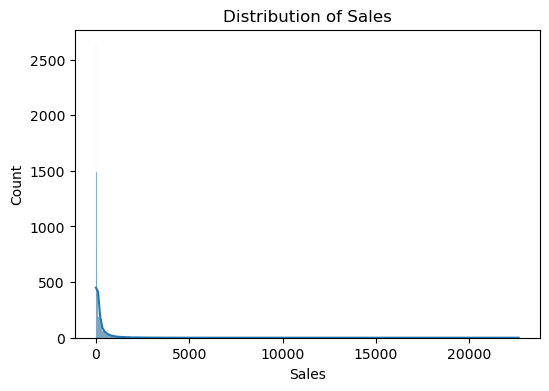

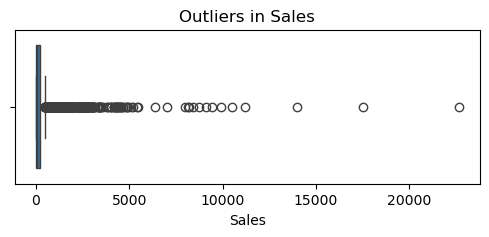

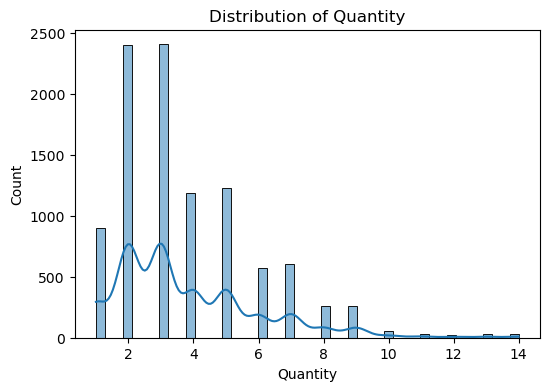

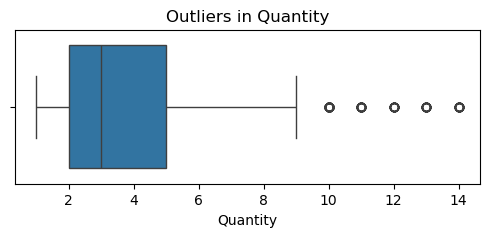

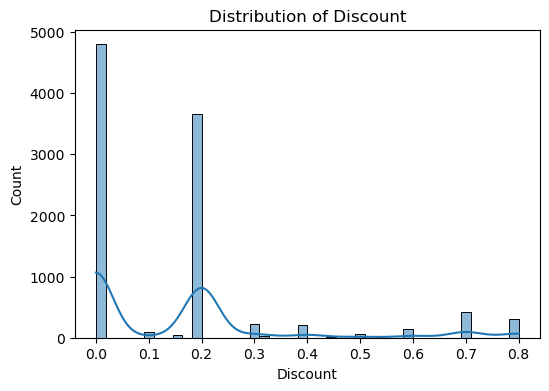

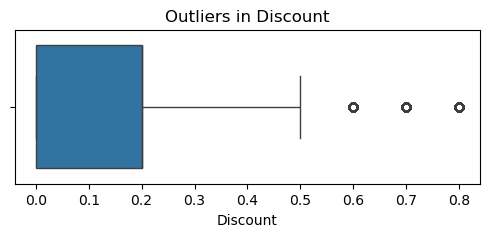

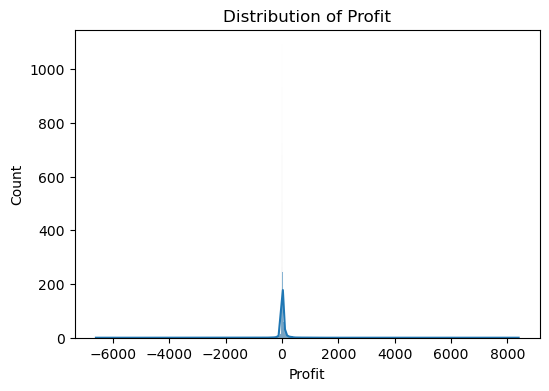

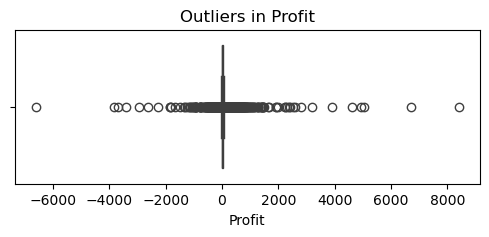

In [80]:
num_cols = df.select_dtypes(include=["float64","int64"]).columns
num_cols = [col for col in num_cols if col not in ["Postal Code","Row ID"]]

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

    plt.figure(figsize=(6,2))
    sns.boxplot(x=df[col])
    plt.title(f"Outliers in {col}")
    plt.show()

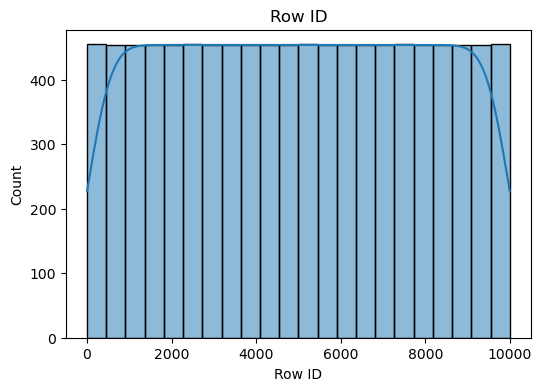

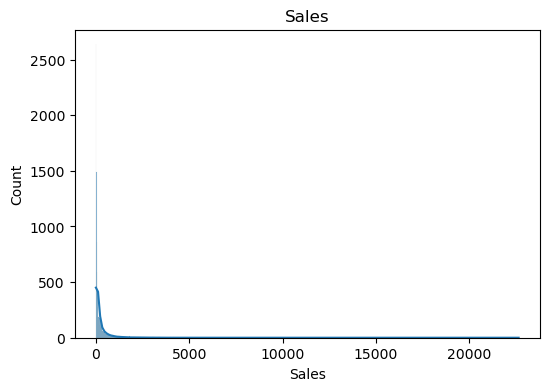

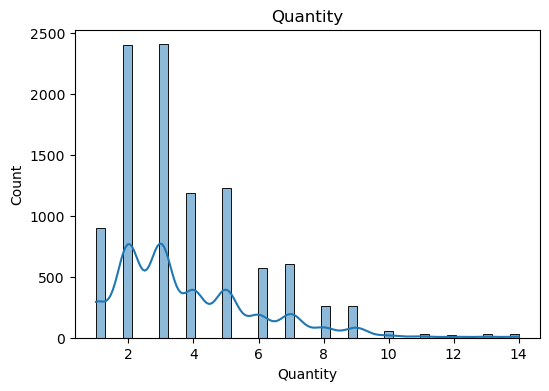

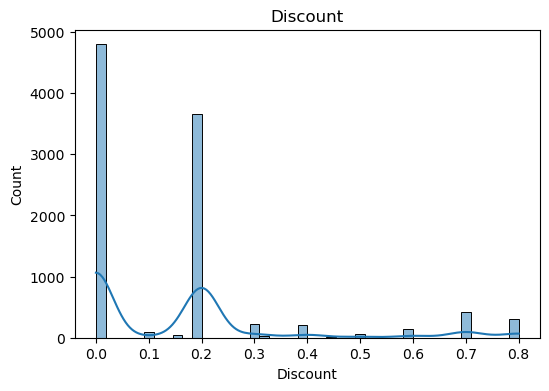

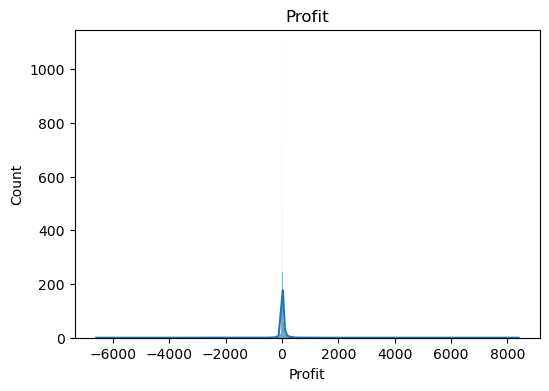

In [81]:
num_cols = df.select_dtypes(include=["float64","int64"]).columns

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()

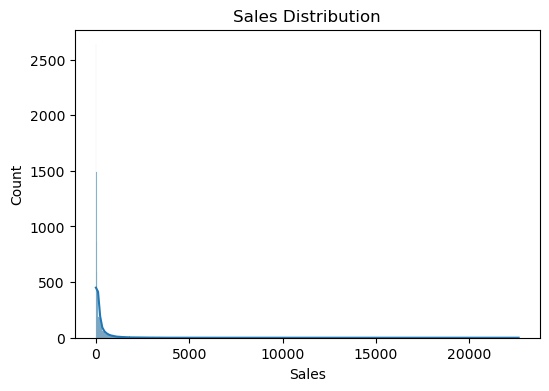

In [82]:
plt.figure(figsize=(6,4))
sns.histplot(df["Sales"],kde=True)
plt.title("Sales Distribution")
plt.show()

In [83]:
#Sales distribution is right-skewed
#Few high-value transactions exist

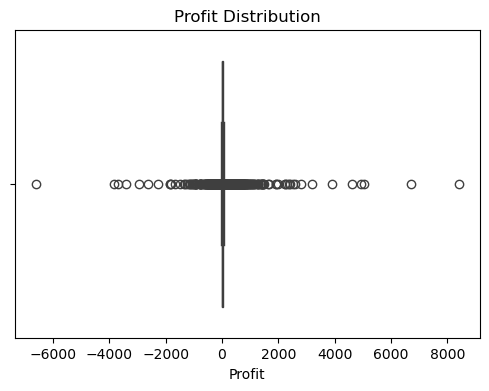

In [84]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df["Profit"])
plt.title("Profit Distribution")
plt.show()

In [85]:
#  Presence of negative profit (loss-making orders)

In [86]:
# Bivariant analysis

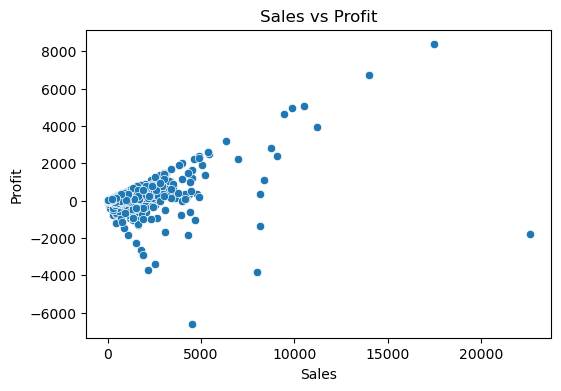

In [87]:
plt.figure(figsize=(6,4))
sns.scatterplot(x="Sales",y="Profit",data=df)
plt.title("Sales vs Profit")
plt.show()

In [88]:
# higher sales do not always gurantee higher profit

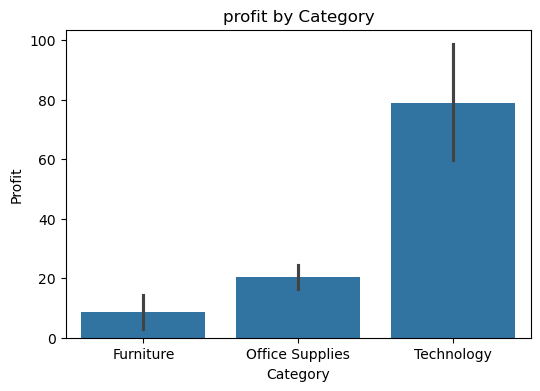

In [89]:
plt.figure(figsize=(6,4))
sns.barplot(x="Category",y="Profit",data=df)
plt.title("profit by Category")
plt.show()

In [90]:
# furniture category shows lower Profitability
# Technology category shows highest Profitability

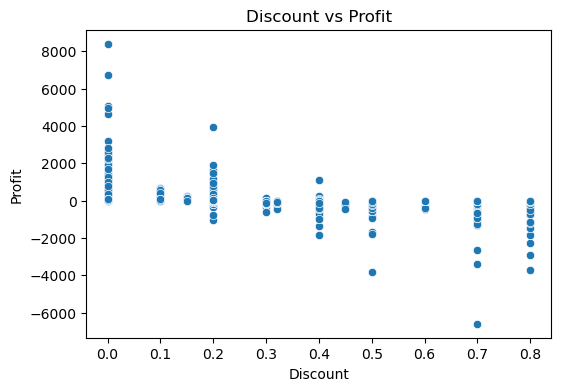

In [91]:
plt.figure(figsize=(6,4))
sns.scatterplot(x="Discount",y="Profit",data=df)
plt.title("Discount vs Profit")
plt.show()

In [92]:
# Higher Discount is strongly associated with negative Profit

In [93]:
df["Shipping Delay"] = (df["Ship Date"] - df["Order Date"]).dt.days

In [94]:
df[["Order Date","Ship Date","Shipping Delay"]].head()

,Order Date,Ship Date,Shipping Delay
1,2020-11-08,2020-11-11,3
2,2020-06-12,2020-06-16,4
3,2019-10-11,2019-10-18,7
4,2019-10-11,2019-10-18,7
5,2018-06-09,2018-06-14,5


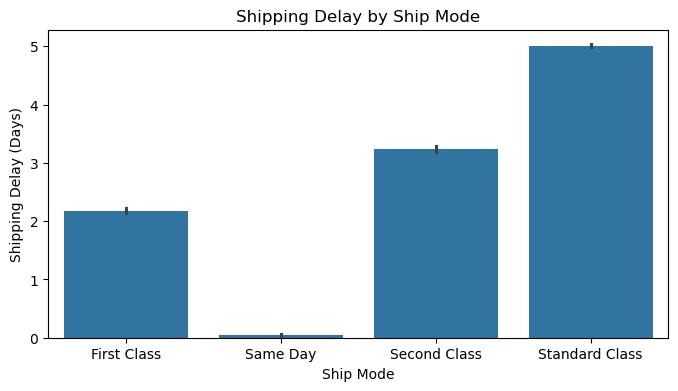

In [95]:
plt.figure(figsize=(8,4))
sns.barplot(x="Ship Mode", y="Shipping Delay", data=df)
plt.title("Shipping Delay by Ship Mode")
plt.xlabel("Ship Mode")
plt.ylabel("Shipping Delay (Days)")
plt.show()

In [ ]:
# Standard class ship mode has more delays because of slow and cheap 

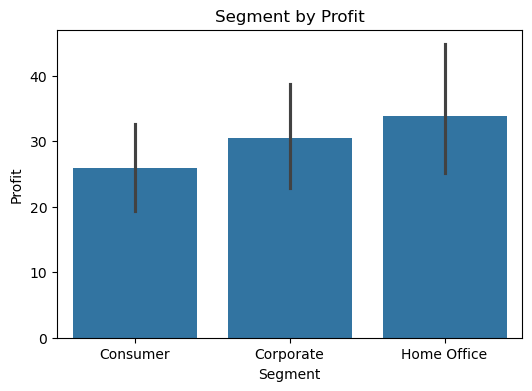

In [96]:
plt.figure(figsize=(6,4))
sns.barplot(x="Segment",y="Profit",data=df)
plt.title("Segment by Profit")
plt.show()

In [97]:
# Consumer Segment is the lowest profitable

In [98]:
# Multivariant Analysis

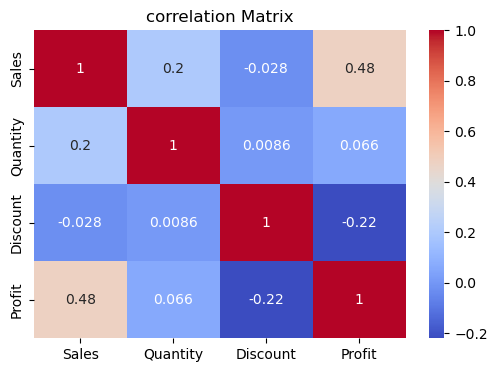

In [99]:
plt.figure (figsize=(6,4))
sns.heatmap(df[["Sales","Quantity","Discount","Profit"]].corr(),annot=True,cmap="coolwarm")
plt.title("correlation Matrix")
plt.show()

In [100]:
# Discount has a negative correlation with Profit & Sales
# Sales & Profit show positive correlation 

In [101]:
# Conclusion
# 1. Sales distribution is right-skewed with high-value outliers.
# 2. Discounts negatively impact profitability.
# 3. Furniture category contributes to lower profit margins.
# 4. Certain regions generate high sales but low profit.
# 5. Shipping delays vary across ship modes.

In [102]:
df.to_csv("E-commerce_sales_cleaned.csv", index=False)